In [1]:
#| label: setup
#| echo: false

import json
import sys
from pathlib import Path

import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import Markdown, display

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(_root / "src"))

import utils

MODEL_ID     = "lgbm_solusdt_l_fw60_2101_2605"
SNAPSHOT_ID  = "solusdt_fw60_2101_2605__21668185"
ARTIFACT_DIR = _root / "artifacts" / MODEL_ID

# ── Feature lists from feature_set.json ──────────────────────────────────────
fs_path = ARTIFACT_DIR / "feature_engineering" / "feature_set.json"
fs = json.loads(fs_path.read_text(encoding="utf-8"))

VARIANTS = {
    "top10"          : fs["top10"],
    "top1_per_group" : fs["top1_per_group"],
    "selected"       : fs["selected"],
}

VARIANT_LABELS = {
    "top10"          : f"Top 10 (n={len(fs['top10'])})",
    "top1_per_group" : f"Top 1/csoport (n={len(fs['top1_per_group'])})",
    "selected"       : f"Összes selected (n={len(fs['selected'])})",
}

# ── Best params ───────────────────────────────────────────────────────────────
bp_path = ARTIFACT_DIR / "search" / "best_params.json"
best_params = json.loads(bp_path.read_text(encoding="utf-8"))

TARGET = "long_mfe_fw60"

display(Markdown(
    "**Variánsok:**\n\n"
    + "\n".join(f"- **{k}**: {len(v)} feature" for k, v in VARIANTS.items())
    + "\n\n**Best params forrás:** `search/best_params.json`"
))

**Variánsok:**

- **top10**: 10 feature
- **top1_per_group**: 17 feature
- **selected**: 131 feature

**Best params forrás:** `search/best_params.json`

In [2]:
#| label: data-load
#| echo: false

conn = utils.open_lab_connection("solusdt")

all_feat_cols = fs["selected"]  # legszélesebb feature set betöltjük, subset-elünk majd
feat_sql = ", ".join(f's."{f}"' for f in all_feat_cols)

df = conn.execute(f"""
    SELECT s.open_time, s.{TARGET}, m.split,
           {feat_sql}
    FROM snap."{SNAPSHOT_ID}" AS s
    INNER JOIN model."{MODEL_ID}__sample" AS m
        ON s.open_time = m.open_time
    ORDER BY s.open_time
""").fetchdf()
conn.close()

df_train = df[df.split == 0].copy().reset_index(drop=True)
df_valid = df[df.split == 1].copy().reset_index(drop=True)

display(Markdown(
    f"**Adathalmaz:** train={len(df_train):,} sor, valid={len(df_valid):,} sor  \n"
    f"Train: {df_train.open_time.min().date()} → {df_train.open_time.max().date()}  \n"
    f"Valid: {df_valid.open_time.min().date()} → {df_valid.open_time.max().date()}"
))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Adathalmaz:** train=37,939 sor, valid=9,504 sor  
Train: 2021-01-01 → 2025-04-30  
Valid: 2025-05-01 → 2026-05-31

In [3]:
#| label: train-models
#| echo: false

LGB_FIXED = {
    "objective"        : "regression",
    "metric"           : "rmse",
    "verbosity"        : -1,
    "n_estimators"     : 600,
    "random_state"     : 42,
    **best_params,
}

models   = {}
preds_tr = {}
preds_va = {}

for vname, feat_list in VARIANTS.items():
    # Nullák medián-imputálása
    X_tr = df_train[feat_list].fillna(df_train[feat_list].median())
    y_tr = df_train[TARGET].astype(float)
    X_va = df_valid[feat_list].fillna(df_train[feat_list].median())
    y_va = df_valid[TARGET].astype(float)

    model = lgb.LGBMRegressor(**LGB_FIXED)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
    )
    models[vname]   = model
    preds_tr[vname] = model.predict(X_tr)
    preds_va[vname] = model.predict(X_va)

    print(f"[{vname}] n_features={len(feat_list)}, "
          f"best_iter={model.best_iteration_}, "
          f"train_rmse={np.sqrt(np.mean((y_tr - preds_tr[vname])**2)):.4f}, "
          f"valid_rmse={np.sqrt(np.mean((y_va - preds_va[vname])**2)):.4f}")

[top10] n_features=10, best_iter=600, train_rmse=0.0094, valid_rmse=0.0050


[top1_per_group] n_features=17, best_iter=600, train_rmse=0.0094, valid_rmse=0.0051


[selected] n_features=131, best_iter=600, train_rmse=0.0094, valid_rmse=0.0050


In [4]:
#| label: decile-utils
#| echo: false

def compute_deciles(y_true, y_score, n_deciles=10):
    """Returns DataFrame: decile (1=lowest, 10=highest score), mean_target, mean_pred, n."""
    labels = pd.qcut(pd.Series(y_score), q=n_deciles, labels=False, duplicates="drop")
    df_d = pd.DataFrame({"target": y_true.values, "pred": y_score, "decile": labels + 1})
    return df_d.groupby("decile").agg(
        mean_target=("target", "mean"),
        mean_pred  =("pred",   "mean"),
        n          =("target", "count"),
    ).reset_index()

def top10_lift(y_true, y_score):
    thr  = np.percentile(y_score, 90)
    mask = y_score >= thr
    return float(np.mean(y_true[mask]) - np.mean(y_true)) if mask.sum() else 0.0

def top10_avg(y_true, y_score):
    thr  = np.percentile(y_score, 90)
    mask = y_score >= thr
    return float(np.mean(y_true[mask])) if mask.sum() else float(np.mean(y_true))

COLORS = {
    "top10"          : "#2196F3",
    "top1_per_group" : "#FF9800",
    "selected"       : "#4CAF50",
}

def top10_ratio(y_true, y_score):
    """Top-decile avg target / overall avg target ratio.  >1.0 = top decile outperforms."""
    thr     = np.percentile(y_score, 90)
    mask    = y_score >= thr
    overall = float(np.mean(y_true))
    if overall == 0 or mask.sum() == 0:
        return float("nan")
    return float(np.mean(y_true[mask])) / overall

## Összefoglaló metrikák

In [5]:
#| label: tbl-summary
#| echo: false

y_tr = df_train[TARGET].astype(float).values
y_va = df_valid[TARGET].astype(float).values

rows = []
for vname in VARIANTS:
    rows.append({
        "Variáns"            : VARIANT_LABELS[vname],
        "n_features"         : len(VARIANTS[vname]),
        "Train RMSE"         : round(np.sqrt(np.mean((y_tr - preds_tr[vname])**2)), 4),
        "Valid RMSE"         : round(np.sqrt(np.mean((y_va - preds_va[vname])**2)), 4),
        "Train top10 avg"    : round(top10_avg(y_tr, preds_tr[vname]), 4),
        "Valid top10 avg"    : round(top10_avg(y_va, preds_va[vname]), 4),
        "Train D10/avg"      : round(top10_ratio(y_tr, preds_tr[vname]), 3),
        "Valid D10/avg"      : round(top10_ratio(y_va, preds_va[vname]), 3),
        "Train top10 lift"   : round(top10_lift(y_tr, preds_tr[vname]), 4),
        "Valid top10 lift"   : round(top10_lift(y_va, preds_va[vname]), 4),
    })

summary_tbl = pd.DataFrame(rows)
display(Markdown(summary_tbl.to_markdown(index=False)))

| Variáns                 |   n_features |   Train RMSE |   Valid RMSE |   Train top10 avg |   Valid top10 avg |   Train D10/avg |   Valid D10/avg |   Train top10 lift |   Valid top10 lift |
|:------------------------|-------------:|-------------:|-------------:|------------------:|------------------:|----------------:|----------------:|-------------------:|-------------------:|
| Top 10 (n=10)           |           10 |       0.0094 |       0.005  |            0.0185 |            0.0087 |           2.401 |           1.839 |             0.0108 |             0.004  |
| Top 1/csoport (n=17)    |           17 |       0.0094 |       0.0051 |            0.0186 |            0.0085 |           2.406 |           1.798 |             0.0108 |             0.0038 |
| Összes selected (n=131) |          131 |       0.0094 |       0.005  |            0.0188 |            0.0086 |           2.436 |           1.83  |             0.0111 |             0.0039 |

## Decilis analízis — Train vs Valid

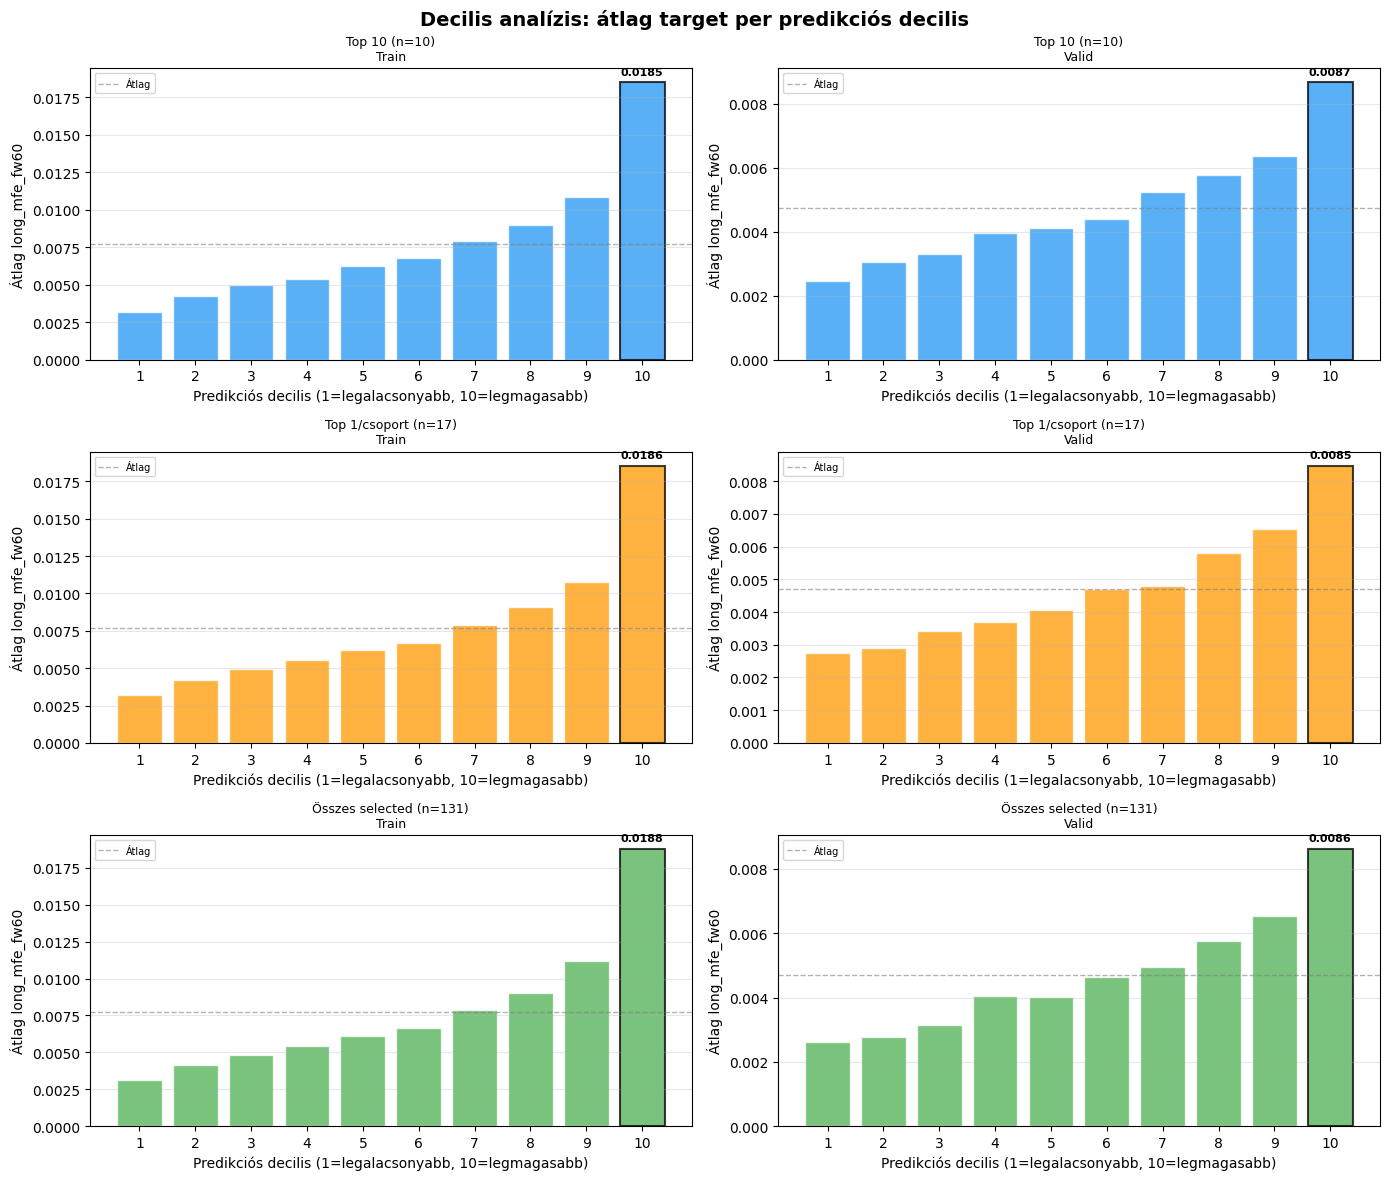

In [6]:
#| label: fig-deciles
#| echo: false
#| fig-width: 14
#| fig-height: 12

y_tr_s = pd.Series(y_tr)
y_va_s = pd.Series(y_va)

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=False)
fig.suptitle("Decilis analízis: átlag target per predikciós decilis", fontsize=14, fontweight="bold")

for row_i, vname in enumerate(VARIANTS):
    d_tr = compute_deciles(y_tr_s, preds_tr[vname])
    d_va = compute_deciles(y_va_s, preds_va[vname])
    clr  = COLORS[vname]
    lbl  = VARIANT_LABELS[vname]

    for col_i, (d, split_lbl) in enumerate([(d_tr, "Train"), (d_va, "Valid")]):
        ax = axes[row_i, col_i]
        bars = ax.bar(d["decile"], d["mean_target"], color=clr, alpha=0.75, edgecolor="white", width=0.8)
        ax.axhline(d["mean_target"].mean(), color="grey", lw=1, ls="--", alpha=0.6, label="Átlag")
        # Top decile highlight
        top_bar = bars[d["decile"].max() - 1]
        top_bar.set_edgecolor("black")
        top_bar.set_linewidth(1.5)
        top_val = d.loc[d["decile"] == d["decile"].max(), "mean_target"].values[0]
        ax.text(d["decile"].max(), top_val + top_val * 0.02,
                f"{top_val:.4f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
        ax.set_title(f"{lbl}\n{split_lbl}", fontsize=9)
        ax.set_xlabel("Predikciós decilis (1=legalacsonyabb, 10=legmagasabb)")
        ax.set_ylabel("Átlag long_mfe_fw60")
        ax.set_xticks(range(1, 11))
        ax.legend(fontsize=7)
        ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("comparison_deciles.png", dpi=120, bbox_inches="tight")
plt.show()

## Top decilis (D10) összehasonlítás

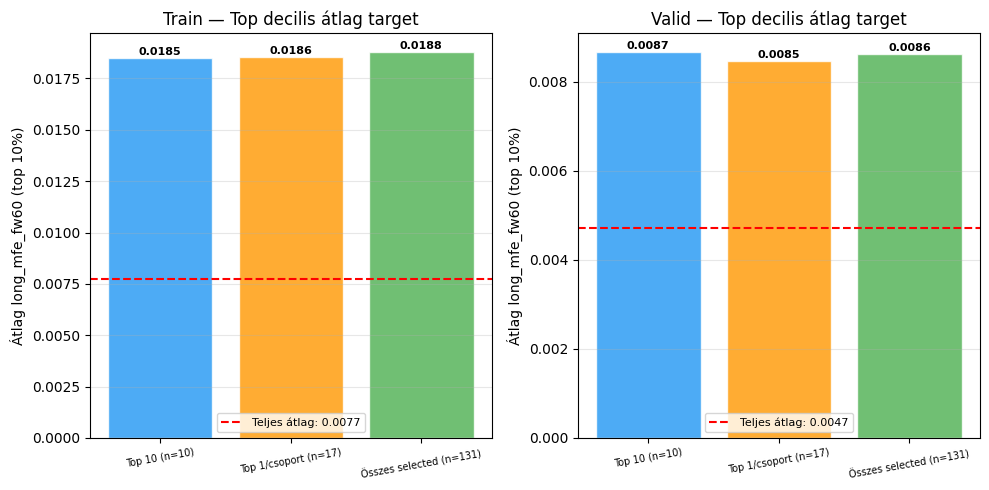

In [7]:
#| label: fig-top10-compare
#| echo: false
#| fig-width: 10
#| fig-height: 5

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax_i, (split_lbl, preds_d, y_s) in enumerate([
    ("Train", preds_tr, y_tr),
    ("Valid", preds_va, y_va),
]):
    avgs   = [top10_avg(y_s, preds_d[v]) for v in VARIANTS]
    lifts  = [top10_lift(y_s, preds_d[v]) for v in VARIANTS]
    labels = [VARIANT_LABELS[v] for v in VARIANTS]
    colors = [COLORS[v] for v in VARIANTS]
    overall = float(np.mean(y_s))

    ax = axes[ax_i]
    bars = ax.bar(labels, avgs, color=colors, alpha=0.8, edgecolor="white")
    ax.axhline(overall, color="red", lw=1.5, ls="--", label=f"Teljes átlag: {overall:.4f}")
    for bar, avg in zip(bars, avgs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + overall*0.005,
                f"{avg:.4f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_title(f"{split_lbl} — Top decilis átlag target")
    ax.set_ylabel("Átlag long_mfe_fw60 (top 10%)")
    ax.tick_params(axis="x", labelsize=7, rotation=10)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("comparison_top10.png", dpi=120, bbox_inches="tight")
plt.show()

## Összes variáns decilis vonalként (Train és Valid)

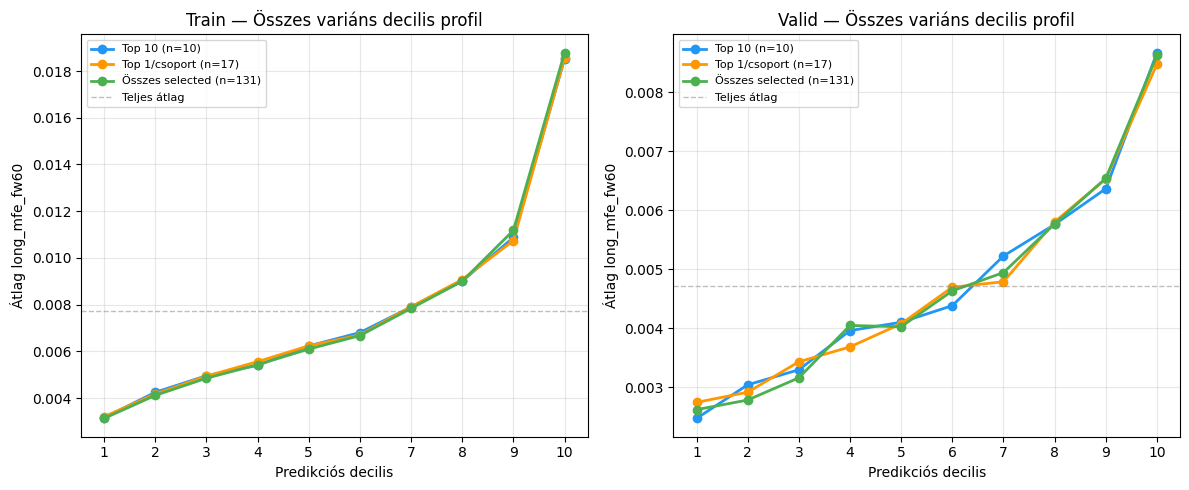

In [8]:
#| label: fig-decile-overlay
#| echo: false
#| fig-width: 12
#| fig-height: 5

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax_i, (split_lbl, preds_d, y_s) in enumerate([
    ("Train", preds_tr, y_tr),
    ("Valid", preds_va, y_va),
]):
    ax = axes[ax_i]
    y_s_series = pd.Series(y_s)
    for vname in VARIANTS:
        d = compute_deciles(y_s_series, preds_d[vname])
        ax.plot(d["decile"], d["mean_target"],
                marker="o", color=COLORS[vname], label=VARIANT_LABELS[vname], linewidth=2)
    ax.axhline(float(np.mean(y_s)), color="grey", lw=1, ls="--", alpha=0.5, label="Teljes átlag")
    ax.set_title(f"{split_lbl} — Összes variáns decilis profil")
    ax.set_xlabel("Predikciós decilis")
    ax.set_ylabel("Átlag long_mfe_fw60")
    ax.set_xticks(range(1, 11))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("comparison_overlay.png", dpi=120, bbox_inches="tight")
plt.show()

## Konklúzió: Train vs Valid top10 lift összehasonlítás

In [9]:
#| label: tbl-conclusion
#| echo: false

rows = []
for vname in VARIANTS:
    tr_avg  = top10_avg(y_tr, preds_tr[vname])
    va_avg  = top10_avg(y_va, preds_va[vname])
    tr_lift = top10_lift(y_tr, preds_tr[vname])
    va_lift = top10_lift(y_va, preds_va[vname])
    overfit = tr_lift - va_lift
    rows.append({
        "Variáns"          : VARIANT_LABELS[vname],
        "Train D10/avg"    : f"{top10_ratio(y_tr, preds_tr[vname]):.3f}x",
        "Valid D10/avg"    : f"{top10_ratio(y_va, preds_va[vname]):.3f}x",
        "Train top10 avg"  : f"{tr_avg:.4f}",
        "Valid top10 avg"  : f"{va_avg:.4f}",
        "Train lift"       : f"{tr_lift:.4f}",
        "Valid lift"       : f"{va_lift:.4f}",
        "Overfit (tr-va)"  : f"{overfit:.4f}",
    })

conc_df = pd.DataFrame(rows)
display(Markdown(conc_df.to_markdown(index=False)))

best_va = max(VARIANTS.keys(), key=lambda v: top10_lift(y_va, preds_va[v]))
display(Markdown(
    f"\n**Legjobb valid lift:** **{VARIANT_LABELS[best_va]}**  \n"
    f"Valid top10 avg = {top10_avg(y_va, preds_va[best_va]):.4f}  \n"
    f"Valid D10/avg ratio = {top10_ratio(y_va, preds_va[best_va]):.3f}x  \n"
    f"Valid lift = {top10_lift(y_va, preds_va[best_va]):.4f}"
))

| Variáns                 | Train D10/avg   | Valid D10/avg   |   Train top10 avg |   Valid top10 avg |   Train lift |   Valid lift |   Overfit (tr-va) |
|:------------------------|:----------------|:----------------|------------------:|------------------:|-------------:|-------------:|------------------:|
| Top 10 (n=10)           | 2.401x          | 1.839x          |            0.0185 |            0.0087 |       0.0108 |       0.004  |            0.0068 |
| Top 1/csoport (n=17)    | 2.406x          | 1.798x          |            0.0186 |            0.0085 |       0.0108 |       0.0038 |            0.0071 |
| Összes selected (n=131) | 2.436x          | 1.830x          |            0.0188 |            0.0086 |       0.0111 |       0.0039 |            0.0072 |


**Legjobb valid lift:** **Top 10 (n=10)**  
Valid top10 avg = 0.0087  
Valid D10/avg ratio = 1.839x  
Valid lift = 0.0040